In [ ]:
!pip install transformers[torch] datasets accelerate evaluate trl peft bitsandbytes -q
!pip install rouge_score scipy -q
!pip install protobuf==4.25.3 -q

In [ ]:
import torch
import warnings
import pandas as pd
from datasets import load_dataset, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq
)
from peft import LoraConfig, get_peft_model, TaskType, AutoPeftModelForSeq2SeqLM
from trl import DPOTrainer, DPOConfig
import evaluate
import numpy as np

warnings.filterwarnings("ignore")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Đang sử dụng thiết bị: {device}")

Đang sử dụng thiết bị: cuda


In [ ]:
MODEL_NAME = "VietAI/vit5-base"

MAX_SAMPLES = 20000

MAX_LENGTH = 512

OUTPUT_SFT_DIR = "sft_adapter_summarization"
OUTPUT_DPO_DIR = "dpo_adapter_summarization"

In [ ]:
# 1. Tải dữ liệu
dataset = load_dataset("nam194/vietnews", split=f"train[:{MAX_SAMPLES}]")

# 2. Chuẩn hóa
def preprocess_data(example):
    example["input_text"] = "tóm tắt: " + example["article"]
    example["target_text"] = example["abstract"]
    return example

dataset = dataset.map(
    preprocess_data,
    remove_columns=["guid", "title", "abstract", "article"]
)

print("Mẫu dữ liệu Tóm tắt:")
print(dataset[0]["input_text"][:200] + "...")
print(dataset[0]["target_text"])

# 3. Xáo trộn và Chia Train/Test
dataset = dataset.shuffle(seed=42)
split_datasets = dataset.train_test_split(test_size=0.1, seed=42)
train_sft_dataset = split_datasets["train"]
test_dataset = split_datasets["test"] # Tập test này chỉ chứa dữ liệu tóm tắt

print(f"\nTổng số mẫu SFT (Train): {len(train_sft_dataset)}")
print(f"Tổng số mẫu (Test): {len(test_dataset)}")

README.md:   0%|          | 0.00/748 [00:00<?, ?B/s]

data/train-00000-of-00001-84acb79f6c6547(…):   0%|          | 0.00/170M [00:00<?, ?B/s]

data/validation-00000-of-00001-210cc51bf(…):   0%|          | 0.00/38.3M [00:00<?, ?B/s]

data/test-00000-of-00001-123f98d55067eb7(…):   0%|          | 0.00/38.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/99134 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/22184 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/22498 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Mẫu dữ liệu Tóm tắt:
tóm tắt: Ngày 27/3 , Cơ_quan Cảnh_sát điều_tra Công_an TP. Hưng_Yên , tỉnh Hưng_Yên cho biết , đơn_vị vừa ra quyết_định khởi_tố vụ án , khởi_tố bị_can đối_với đối_tượng Mai_Văn_Thương ( SN 1989 , trú ...
Với bản_tính ham chơi , lười làm , có nhiều tiền_án tiền_sự , lại nghiện ma_tuý , Thương đã đột_nhập vào nhà chú ruột để trộm hơn 1 tạ thóc và hơn 8 triệu đồng mang đi tiêu_xài .

Tổng số mẫu SFT (Train): 18000
Tổng số mẫu (Test): 2000


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_sft_data(examples):
    model_inputs = tokenizer(
        examples["input_text"],
        max_length=MAX_LENGTH,
        truncation=True,
        padding="max_length"
    )
    labels = tokenizer(
        text_target=examples["target_text"],
        max_length=MAX_LENGTH,
        truncation=True,
        padding="max_length"
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_train_sft_dataset = train_sft_dataset.map(
    tokenize_sft_data,
    batched=True,
    remove_columns=["input_text", "target_text"]
)
print("Tokenization SFT hoàn tất.")

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/820k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/18000 [00:00<?, ? examples/s]

Tokenization SFT hoàn tất.


In [ ]:
# Tải mô hình và Cấu hình LoRA (PEFT)
model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME,
    load_in_8bit=True,
    device_map="auto"
)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q", "v"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM
)

sft_model = get_peft_model(model, lora_config)
sft_model.print_trainable_parameters()

config.json:   0%|          | 0.00/702 [00:00<?, ?B/s]

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


pytorch_model.bin:   0%|          | 0.00/904M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/904M [00:00<?, ?B/s]

trainable params: 1,769,472 || all params: 227,720,448 || trainable%: 0.7770


In [ ]:
#Huấn luyện SFT
sft_training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_SFT_DIR,
    num_train_epochs=1,  # Train 3-5 epochs cho 5000 mẫu
    per_device_train_batch_size=6, # Tăng batch size
    logging_steps=100,
    learning_rate=3e-4,
    save_strategy="epoch",
    report_to="none",
)

data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=sft_model)

sft_trainer = Seq2SeqTrainer(
    model=sft_model,
    args=sft_training_args,
    train_dataset=tokenized_train_sft_dataset,
    data_collator=data_collator,
)

print("\n--- BẮT ĐẦU HUẤN LUYỆN SFT (Tóm tắt) ---")
sft_trainer.train()
print("--- HUẤN LUYỆN SFT HOÀN TẤT ---")
sft_trainer.save_model(OUTPUT_SFT_DIR)


--- BẮT ĐẦU HUẤN LUYỆN SFT (Tóm tắt) ---


Step,Training Loss
100,4.000000
200,0.324700
300,0.293500
400,0.265500
500,0.258000
600,0.259000
700,0.257300
800,0.262700
900,0.246600
1000,0.256700


--- HUẤN LUYỆN SFT HOÀN TẤT ---


In [ ]:
#Chuẩn bị Dữ liệu DPO
df_sft = train_sft_dataset.to_pandas()

df_dpo = pd.DataFrame()
df_dpo["prompt"] = df_sft["input_text"]
df_dpo["chosen"] = df_sft["target_text"]
df_dpo["rejected"] = df_sft["target_text"].shift(-1) # Lấy tóm tắt của mẫu tiếp theo
df_dpo = df_dpo.dropna() # Xóa hàng cuối cùng

print(f"Số lượng mẫu DPO: {len(df_dpo)}")
print("\nMẫu dữ liệu DPO (chỉ tóm tắt):")
print(f"PROMPT:   {df_dpo.iloc[0]['prompt'][:100]}...")
print(f"CHOSEN:   {df_dpo.iloc[0]['chosen']}")
print(f"REJECTED: {df_dpo.iloc[0]['rejected']}")

dpo_dataset = Dataset.from_pandas(df_dpo)

Số lượng mẫu DPO: 17999

Mẫu dữ liệu DPO (chỉ tóm tắt):
PROMPT:   tóm tắt: Ngày 17/6 , đại_diện Công_an huyện Hoà_Vang , TP. Đà_Nẵng cho biết , đơn_vị đã có quyết_địn...
CHOSEN:   Trong quá_trình điều_tra , các trinh_sát phát_hiện 1 kẻ có biệt_danh " Chất_Độc " phân_phối ma_tuý cho các con_nghiện . Tuy_nhiên , đối_tượng ma_mãnh nên việc tìm ra tung_tích của hắn rất khó_khăn .
REJECTED: " Nếu tình_hình này còn kéo_dài , giải_pháp cuối_cùng phải thực_hiện là luân_phiên cấp_nước theo giờ tại từng khu_vực " - ông Hồ_Hương , tổng_giám_đốc Công_ty CP Cấp_nước Đà_Nẵng ( Dawaco ) nói .


In [ ]:
#Huấn luyện DPO
# 1. Tải mô hình SFT
dpo_model = AutoPeftModelForSeq2SeqLM.from_pretrained(
    OUTPUT_SFT_DIR,
    is_trainable=True,
    device_map="auto",
    torch_dtype=torch.float16
)
dpo_model.config.pretraining_screen_size_precision = "hidden_size"

# 2. Cấu hình DPO
dpo_training_args = DPOConfig(
    output_dir=OUTPUT_DPO_DIR,
    num_train_epochs=1,
    per_device_train_batch_size=10,
    logging_steps=100,
    learning_rate=1e-5,
    remove_unused_columns=False,
    save_strategy="epoch",
    report_to="none",
    beta=0.1,  # Tham số DPO
    max_length=MAX_LENGTH,
)

# 3. Khởi tạo DPOTrainer
dpo_trainer = DPOTrainer(
    model=dpo_model,
    ref_model=None,
    args=dpo_training_args,
    train_dataset=dpo_dataset,
    processing_class=tokenizer,
)

print("\n--- BẮT ĐẦU HUẤN LUYỆN DPO ---")
dpo_trainer.train()
print("--- HUẤN LUYỆN DPO HOÀN TẤT ---")
dpo_trainer.save_model(OUTPUT_DPO_DIR)

`torch_dtype` is deprecated! Use `dtype` instead!


Extracting prompt in train dataset:   0%|          | 0/17999 [00:00<?, ? examples/s]

Applying chat template to train dataset:   0%|          | 0/17999 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/17999 [00:00<?, ? examples/s]

The model is already on multiple devices. Skipping the move to device specified in `args`.



--- BẮT ĐẦU HUẤN LUYỆN DPO ---


Step,Training Loss
100,4.847000
200,1.085000
300,0.370100
400,0.315400
500,0.199700
600,0.195700
700,0.162200
800,0.203400
900,0.085400
1000,0.095900


--- HUẤN LUYỆN DPO HOÀN TẤT ---


In [ ]:
#Lưu và Tải mô hình
import os
import shutil
import platform

print(f"Đang nén thư mục '{OUTPUT_SFT_DIR}'...")
shutil.make_archive("sft_adapter_summary_archive", 'zip', OUTPUT_SFT_DIR)

print(f"Đang nén thư mục '{OUTPUT_DPO_DIR}'...")
shutil.make_archive("dpo_adapter_summary_archive", 'zip', OUTPUT_DPO_DIR)
print("Đã nén 2 file zip.")

# Hướng dẫn tải
if 'google.colab' in str(get_ipython()):
    print("Phát hiện Colab. Đang tải file...")
    from google.colab import files
    files.download('sft_adapter_summary_archive.zip')
    files.download('dpo_adapter_summary_archive.zip')
else:
    print("Phát hiện Kaggle. Vui lòng tải file từ tab 'Data' -> 'Output' bên tay phải.")

Đang nén thư mục 'sft_adapter_summarization'...
Đang nén thư mục 'dpo_adapter_summarization'...
Đã nén 2 file zip.
Phát hiện Colab. Đang tải file...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#Tải các mô hình để Đánh giá
torch.cuda.empty_cache()

print("Đang tải 3 mô hình (Base, SFT, DPO)...")
# 1. Tải mô hình Pre-trained (Base)
model_base = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

# 2. Tải mô hình SFT
model_sft = AutoPeftModelForSeq2SeqLM.from_pretrained(
    OUTPUT_SFT_DIR,
    torch_dtype=torch.float16,
    device_map="auto"
)
model_sft = model_sft.merge_and_unload()

# 3. Tải mô hình DPO
model_dpo = AutoPeftModelForSeq2SeqLM.from_pretrained(
    OUTPUT_DPO_DIR,
    torch_dtype=torch.float16,
    device_map="auto"
)
model_dpo = model_dpo.merge_and_unload()

print("Đã tải 3 mô hình và sẵn sàng đánh giá.")

Đang tải 3 mô hình (Base, SFT, DPO)...
Đã tải 3 mô hình và sẵn sàng đánh giá.


In [ ]:
#Chạy Đánh giá (ROUGE-L)
print("--- BẮT ĐẦU ĐÁNH GIÁ (Chỉ Tóm tắt) ---")
rouge_metric = evaluate.load("rouge")
results = {}

# Chuẩn bị dữ liệu test
test_inputs = test_dataset["input_text"]
test_references = test_dataset["target_text"]
# Hàm helper để chạy generate
def generate_predictions(model, test_inputs):
    predictions = []
    for text in test_inputs:
        inputs = tokenizer(text, return_tensors="pt", max_length=MAX_LENGTH, truncation=True).to(device)
        with torch.no_grad():
            output_ids = model.generate(
                inputs.input_ids,
                max_new_tokens=MAX_LENGTH,
                num_beams=3
            )[0]
        prediction = tokenizer.decode(output_ids, skip_special_tokens=True)
        predictions.append(prediction)
    return predictions

# Lặp qua 3 mô hình
for model_name, model_obj in [("Base", model_base), ("SFT", model_sft), ("DPO", model_dpo)]:
    print(f"\nĐang đánh giá mô hình: {model_name}")
    model_results = {}

    # Tóm tắt (ROUGE)
    preds = generate_predictions(model_obj, test_inputs)
    rouge_score = rouge_metric.compute(predictions=preds, references=test_references)
    model_results["ROUGE-L"] = rouge_score["rougeL"] * 100

    results[model_name] = model_results
    print(f"Kết quả {model_name}: {model_results}")

print("\n--- ĐÁNH GIÁ HOÀN TẤT ---")

--- BẮT ĐẦU ĐÁNH GIÁ (Chỉ Tóm tắt) ---

Đang đánh giá mô hình: Base
Kết quả Base: {'ROUGE-L': np.float64(12.617447305285957)}

Đang đánh giá mô hình: SFT
Kết quả SFT: {'ROUGE-L': np.float64(37.61144822277672)}

Đang đánh giá mô hình: DPO
Kết quả DPO: {'ROUGE-L': np.float64(35.49808846103277)}

--- ĐÁNH GIÁ HOÀN TẤT ---


In [ ]:
df_results = pd.DataFrame(results).T
df_results = df_results.round(2)

print("BẢNG SO SÁNH KẾT QUẢ CUỐI CÙNG (TÓM TẮT):")
print(df_results)

BẢNG SO SÁNH KẾT QUẢ CUỐI CÙNG (TÓM TẮT):
      ROUGE-L
Base    12.62
SFT     37.61
DPO     35.50



===== BIỂU ĐỒ SO SÁNH ROUGE-L =====


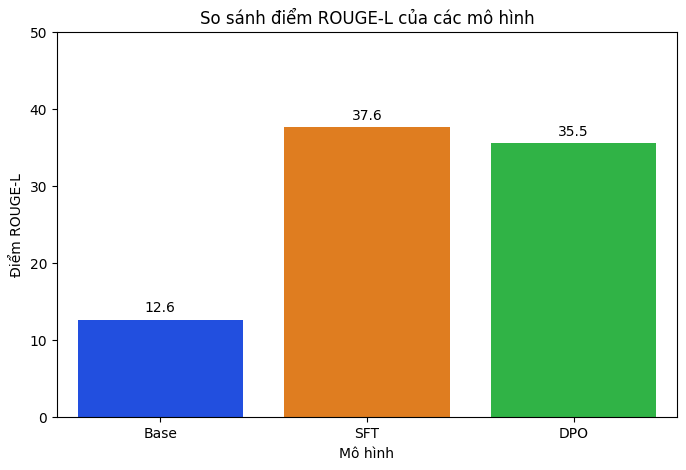

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n===== BIỂU ĐỒ SO SÁNH ROUGE-L =====")

# Tạo biểu đồ cột
plt.figure(figsize=(8, 5))
sns.barplot(x=df_results.index, y='ROUGE-L', data=df_results, palette='bright')

# Thêm nhãn và tiêu đề
plt.title('So sánh điểm ROUGE-L của các mô hình')
plt.xlabel('Mô hình')
plt.ylabel('Điểm ROUGE-L')
plt.ylim(0, 50)

# Hiển thị giá trị trên cột
for index, row in df_results.iterrows():
    plt.text(index, row['ROUGE-L'] + 1, round(row['ROUGE-L'], 1), color='black', ha="center")

plt.show()

In [ ]:
def Demo(prompt_text, model_choice=2):
    """
    Chạy demo tóm tắt với 1 trong 3 mô hình.
    model_choice:
      1 = Base
      2 = SFT (Mặc định)
      3 = DPO
    """
    print(f"Input: {prompt_text}")
    # Thêm tiền tố "tóm tắt:"
    full_prompt = "tóm tắt: " + prompt_text

    inputs = tokenizer(full_prompt, return_tensors="pt", max_length=512, truncation=True).to(device)

    # --- BẮT ĐẦU THAY ĐỔI ---

    # 1. Chọn mô hình dựa trên model_choice
    selected_model = None
    model_name = ""
    if model_choice == 1:
        selected_model = model_base
        model_name = "Base"
    elif model_choice == 2:
        selected_model = model_sft
        model_name = "SFT"
    elif model_choice == 3:
        selected_model = model_dpo # (Giả sử 'db' là 'dpo')
        model_name = "DPO"
    else:
        print(f"Lựa chọn '{model_choice}' không hợp lệ. Mặc định dùng SFT (2).")
        selected_model = model_sft
        model_name = "SFT (Mặc định)"

    print(f"--- Đang chạy demo với mô hình: {model_name} ---")

    with torch.no_grad():
        # 2. Dùng selected_model để generate
        outputs = selected_model.generate( # Sử dụng mô hình đã chọn
            **inputs,
            max_new_tokens=256,
            early_stopping=True,
            num_beams=5,
            no_repeat_ngram_size=2
        )
    # --- KẾT THÚC THAY ĐỔI ---

    result = tokenizer.decode(outputs[0], skip_special_tokens=True)
    print(f"Output ({model_name}): {result}\n" + "-"*20)
    return result

# --- CÁCH SỬ DỤNG ---
demo_text = "dChào các bạn, mình tên là Mai Anh, năm nay mình 9 tuổi và hiện đang học lớp 3. Mình sống cùng gia đình ở một ngôi nhà nhỏ gần công viên. Mình rất thích học Toán và Tiếng Việt, nhưng môn vẽ thì mình cũng rất yêu thích. Ngoài học, mình thích chơi cầu lông và đọc sách, nhất là truyện cổ tích. Mình có một chú mèo tên là Miu, nó rất dễ thương và hay chơi đùa với mình. Mình luôn cố gắng học tốt để sau này có thể trở thành bác sĩ giúp đỡ mọi người. Hy vọng sẽ kết bạn được với nhiều bạn trong lớp!"



In [ ]:
print("===== CHẠY THỬ MÔ HÌNH BASE (1) =====")
Demo(demo_text, model_choice=1)

===== CHẠY THỬ MÔ HÌNH BASE (1) =====
Input: dChào các bạn, mình tên là Mai Anh, năm nay mình 9 tuổi và hiện đang học lớp 3. Mình sống cùng gia đình ở một ngôi nhà nhỏ gần công viên. Mình rất thích học Toán và Tiếng Việt, nhưng môn vẽ thì mình cũng rất yêu thích. Ngoài học, mình thích chơi cầu lông và đọc sách, nhất là truyện cổ tích. Mình có một chú mèo tên là Miu, nó rất dễ thương và hay chơi đùa với mình. Mình luôn cố gắng học tốt để sau này có thể trở thành bác sĩ giúp đỡ mọi người. Hy vọng sẽ kết bạn được với nhiều bạn trong lớp!
--- Đang chạy demo với mô hình: Base ---
Output (Base): *:+ mình ở một ngôi nhà nhỏ gần công viên. Mình có một chú mèo tên là Miu, nó rất dễ thương._ mình.
--------------------


'*:+ mình ở một ngôi nhà nhỏ gần công viên. Mình có một chú mèo tên là Miu, nó rất dễ thương._ mình.'

In [ ]:
print("\n===== CHẠY THỬ MÔ HÌNH SFT (2) =====")
Demo(demo_text, model_choice=2)



===== CHẠY THỬ MÔ HÌNH SFT (2) =====
Input: dChào các bạn, mình tên là Mai Anh, năm nay mình 9 tuổi và hiện đang học lớp 3. Mình sống cùng gia đình ở một ngôi nhà nhỏ gần công viên. Mình rất thích học Toán và Tiếng Việt, nhưng môn vẽ thì mình cũng rất yêu thích. Ngoài học, mình thích chơi cầu lông và đọc sách, nhất là truyện cổ tích. Mình có một chú mèo tên là Miu, nó rất dễ thương và hay chơi đùa với mình. Mình luôn cố gắng học tốt để sau này có thể trở thành bác sĩ giúp đỡ mọi người. Hy vọng sẽ kết bạn được với nhiều bạn trong lớp!
--- Đang chạy demo với mô hình: SFT ---
Output (SFT): * mình tên là Mai Anh, năm nay mình 9 tuổi và hiện đang học lớp 3. Mình sống cùng gia đình ở một ngôi nhà nhỏ gần công viên. Ngoài học, mình thích chơi cầu lông và đọc sách.
--------------------


'* mình tên là Mai Anh, năm nay mình 9 tuổi và hiện đang học lớp 3. Mình sống cùng gia đình ở một ngôi nhà nhỏ gần công viên. Ngoài học, mình thích chơi cầu lông và đọc sách.'

In [ ]:
print("\n===== CHẠY THỬ MÔ HÌNH DPO (3) =====")
Demo(demo_text, model_choice=3)


===== CHẠY THỬ MÔ HÌNH DPO (3) =====
Input: dChào các bạn, mình tên là Mai Anh, năm nay mình 9 tuổi và hiện đang học lớp 3. Mình sống cùng gia đình ở một ngôi nhà nhỏ gần công viên. Mình rất thích học Toán và Tiếng Việt, nhưng môn vẽ thì mình cũng rất yêu thích. Ngoài học, mình thích chơi cầu lông và đọc sách, nhất là truyện cổ tích. Mình có một chú mèo tên là Miu, nó rất dễ thương và hay chơi đùa với mình. Mình luôn cố gắng học tốt để sau này có thể trở thành bác sĩ giúp đỡ mọi người. Hy vọng sẽ kết bạn được với nhiều bạn trong lớp!
--- Đang chạy demo với mô hình: DPO ---
Output (DPO): * mình tên là Mai Anh, năm nay mình 9 tuổi và hiện đang học lớp 3. Mình sống cùng gia đình ở một ngôi nhà nhỏ gần công viên. Ngoài học, mình thích chơi cầu lông và đọc sách, nhất là truyện cổ tích.
--------------------


'* mình tên là Mai Anh, năm nay mình 9 tuổi và hiện đang học lớp 3. Mình sống cùng gia đình ở một ngôi nhà nhỏ gần công viên. Ngoài học, mình thích chơi cầu lông và đọc sách, nhất là truyện cổ tích.'